# MSBD 566 — Lecture 2: Data Understanding & Quality Assessment
## Exploratory Data Analysis (EDA)

**Dataset:** Diabetes 130-US Hospitals (1999–2008) — [UCI ML Repository #296](https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008)

**Our semester-long goal (Business Understanding):**
> *Identify patients at high risk of 30-day hospital readmission so care teams can intervene before discharge.*

This is the **same dataset we will use all semester.** Every week we move one step further along the CRISP-DM cycle. By the end of the course, you will have built, evaluated, and interpreted a real predictive model for hospital readmission.

| CRISP-DM Stage | When we do it |
|---|---|
| 1. Business Understanding | Week 1 (done!) |
| 2. **Data Understanding** | **Today** |
| 3. Data Preparation / Feature Engineering | Week 3 |
| 4. Modeling | Weeks 4–8, 12 |
| 5. Evaluation | Week 6 + throughout |
| 6. Deployment considerations | Week 13 |


In [ ]:
#if you havent installed the required libraries yet, please use following command.
#!pip install pandas numpy matplotlib seaborn

---
# 0. Setup: Import Libraries

We use four core libraries — you will see these in *every* data science project:

- **pandas** — tables of data (think: Excel, but programmable)
- **numpy** — fast numerical operations
- **matplotlib** — basic plotting
- **seaborn** — prettier statistical plots, built on top of matplotlib


In [1]:
# Import the libraries we need and give them their standard short nicknames.
# These nicknames (pd, np, plt, sns) are universal conventions — every tutorial,
# StackOverflow answer, and colleague's code will use the same ones.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings: let pandas show us up to 100 columns/rows instead of hiding them with "..."
# Our dataset has 50 columns, so this matters!
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# Check versions — useful when debugging ("it works on my machine" problems)
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 2.2.3
numpy version: 2.1.3


---
# 1. Load the Dataset

The code below **downloads the data automatically** from the UCI repository the first time you run it, and saves two files next to this notebook:

- `diabetic_data.csv` — the main data: **101,766 hospital encounters**, 50 columns
- `IDS_mapping.csv` — a lookup table that translates numeric ID codes (like `admission_type_id = 1`) into human-readable labels (like "Emergency")

> 💡 **Good practice:** never hard-code a path like `C:/Users/myname/Desktop/data.csv` — your code will break on everyone else's computer. Downloading the data in code (or using relative paths) makes your notebook **reproducible**: anyone can run it, anywhere. Reproducibility shows up again in Week 13 (Responsible AI).


In [2]:
import os
import urllib.request
import zipfile

DATA_URL = "https://archive.ics.uci.edu/static/public/296/diabetes+130-us+hospitals+for+years+1999-2008.zip"

# Only download if we don't already have the file (so re-running the notebook is fast)
if not os.path.exists("diabetic_data.csv"):
    print("Downloading dataset from UCI (about 3.5 MB compressed)...")
    urllib.request.urlretrieve(DATA_URL, "diabetes_data.zip")
    with zipfile.ZipFile("diabetes_data.zip") as z:
        z.extractall(".")          # extracts diabetic_data.csv and IDS_mapping.csv
    print("Done! Files extracted.")
else:
    print("Dataset already downloaded — using the local copy.")

Done! Files extracted.


In [3]:
# Read the main CSV file into a pandas DataFrame.
# A DataFrame is pandas' table object: rows = observations, columns = variables.
data = pd.read_csv("diabetic_data.csv")

# ALWAYS check the size of what you just loaded.
# .shape returns (number_of_rows, number_of_columns)
print("Rows (hospital encounters):", data.shape[0])
print("Columns (variables):       ", data.shape[1])

Rows (hospital encounters): 101766
Columns (variables):        50


---
# 2. First Look: Structure of the Data

**CRISP-DM Data Understanding — Question 1: What do we have?**

Before any analysis, answer the basics:
- How big is the dataset?
- What variables (columns) do we have, and what type is each one?
- What does a row actually represent?


In [4]:
# .head() shows the first 5 rows — your first visual contact with the data.
# Skim it: Do the values look reasonable? Anything surprising?
data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In this instance, I believe that the question marks could possible mean the data is missing. So from a quick inspection, it appears that weight has some missingness, medical speciality has some missingness, payer_code has some missingness, diag_1 and diag_3 has some missingness. So far these values are using question marks. However, max_glu_serum and A1Cresult are using the standard notation of NaN.

In [5]:
# .info() lists every column with its data type and how many non-null values it has.
#   - object  = text/categorical (e.g., race, gender, age brackets)
#   - int64   = whole numbers (e.g., time_in_hospital)
# Notice: pandas says there are NO missing values (all columns show 101766 non-null).
# Spoiler: that is FALSE. We'll find out why in Section 4.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
# .describe() gives summary statistics for the NUMERIC columns:
# count, mean, std (spread), min, quartiles, max.
# Scan the min/max values: do any look impossible or suspicious?
data.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


I am not sure on what looks suspicious, but I can't understand the encounter_id or the patient_nbr.

In [7]:
# One row = one hospital ENCOUNTER. But can the same PATIENT appear multiple times?
# .nunique() counts distinct values in a column.
print("Total encounters (rows):    ", len(data))
print("Unique patients:            ", data['patient_nbr'].nunique())
print("Encounters that are repeat visits:", len(data) - data['patient_nbr'].nunique())

Total encounters (rows):     101766
Unique patients:             71518
Encounters that are repeat visits: 30248


**⚠️ Important discovery:** ~30,000 encounters are *repeat visits by the same patient*. One patient can contribute many rows.

Why does this matter? Two reasons:
1. Rows are **not independent** — a statistical assumption many models make.
2. If the *same patient* ends up in both our training and test data later, the model can "cheat" by recognizing them. This is a form of **data leakage** — we'll return to it in Section 9.


---
# 3. Understand the Variables — Especially the Target

**CRISP-DM Data Understanding — What does each variable *mean*?**

Real datasets come with codebooks. Our `IDS_mapping.csv` translates three coded columns into words. And most importantly: which column is our **outcome (target)** — the thing we want to predict?


In [8]:
# Load the mapping file. It has three small lookup tables stacked in one CSV,
# separated by blank lines, so we read it without a header and slice it by rows.
feature_map = pd.read_csv("IDS_mapping.csv", header=None)

# Build Python dictionaries {code -> label} for each of the three coded columns.
# dict(zip(keys, values)) pairs up two lists into a dictionary.
admission_type      = dict(zip(feature_map[0][1:9].astype(int),   feature_map[1][1:9]))
discharge_disposition = dict(zip(feature_map[0][11:41].astype(int), feature_map[1][11:41]))
admission_source    = dict(zip(feature_map[0][43:68].astype(int), feature_map[1][43:68]))

# Peek at one of them: what does admission_type_id = 1 mean?
admission_type

{1: 'Emergency',
 2: 'Urgent',
 3: 'Elective',
 4: 'Newborn',
 5: 'Not Available',
 6: nan,
 7: 'Trauma Center',
 8: 'Not Mapped'}

In [9]:
# Use .map() to create human-readable versions of the coded columns.
# We create NEW columns (with _desc suffix) instead of overwriting the originals —
# keeping raw data intact is a good habit.
data['admission_type_desc']      = data['admission_type_id'].map(admission_type)
data['discharge_disposition_desc'] = data['discharge_disposition_id'].map(discharge_disposition)
data['admission_source_desc']    = data['admission_source_id'].map(admission_source)

# .value_counts() counts how many times each category appears —
# THE single most useful EDA command for categorical data.
data['admission_type_desc'].value_counts()

,count
admission_type_desc,
Emergency,53990
Elective,18869
Urgent,18480
Not Available,4785
Not Mapped,320
Trauma Center,21
Newborn,10


In [10]:
# Use .map() to create human-readable versions of the coded columns.
# We create NEW columns (with _desc suffix) instead of overwriting the originals —
# keeping raw data intact is a good habit.
data['admission_type_desc']      = data['admission_type_id'].map(admission_type)
data['discharge_disposition_desc'] = data['discharge_disposition_id'].map(discharge_disposition)
data['admission_source_desc']    = data['admission_source_id'].map(admission_source)

# .value_counts() counts how many times each category appears —
# THE single most useful EDA command for categorical data.
data['discharge_disposition_desc'].value_counts()

,count
discharge_disposition_desc,
Discharged to home,60234
Discharged/transferred to SNF,13954
Discharged/transferred to home with home health service,12902
Discharged/transferred to another short term hospital,2128
Discharged/transferred to another rehab fac including rehab units of a hospital .,1993
Expired,1642
Discharged/transferred to another type of inpatient care institution,1184
Not Mapped,989
Discharged/transferred to ICF,815


In [11]:
# Use .map() to create human-readable versions of the coded columns.
# We create NEW columns (with _desc suffix) instead of overwriting the originals —
# keeping raw data intact is a good habit.
data['admission_type_desc']      = data['admission_type_id'].map(admission_type)
data['discharge_disposition_desc'] = data['discharge_disposition_id'].map(discharge_disposition)
data['admission_source_desc']    = data['admission_source_id'].map(admission_source)

# .value_counts() counts how many times each category appears —
# THE single most useful EDA command for categorical data.
data['admission_source_desc'].value_counts()

,count
admission_source_desc,
Emergency Room,57494
Physician Referral,29565
Transfer from a hospital,3187
Transfer from another health care facility,2264
Clinic Referral,1104
Transfer from a Skilled Nursing Facility (SNF),855
HMO Referral,187
Not Mapped,161
Not Available,125


### 3.1 The Target Variable: `readmitted`

Our business question is about **30-day readmission**. The dataset's `readmitted` column has three values:

- `<30` — readmitted within 30 days ← *this is what we want to catch!*
- `>30` — readmitted, but after 30 days
- `NO` — not readmitted


In [12]:
# Count each outcome, and show proportions (normalize=True gives fractions).
print(data['readmitted'].value_counts())
print()
print(data['readmitted'].value_counts(normalize=True).round(3))

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

readmitted
NO     0.539
>30    0.349
<30    0.112
Name: proportion, dtype: float64


In [13]:
# For our business question, we care about: readmitted within 30 days — YES or NO.
# Create a binary target column: 1 if '<30', else 0.
# (x == '<30') gives True/False; .astype(int) converts to 1/0.
data['readmit_30'] = (data['readmitted'] == '<30').astype(int)

print("30-day readmission rate:", round(data['readmit_30'].mean() * 100, 1), "%")

30-day readmission rate: 11.2 %


---
# 4. Data Quality: Missing Values

**CRISP-DM Data Understanding — Question 3: What is wrong with the data?**

`.info()` claimed zero missing values. But look at the actual values — this dataset marks missing data with a `'?'` character. Pandas doesn't know `'?'` means missing, so it counts it as a normal value!

> 🔑 **Lesson:** *every dataset encodes "missing" differently* — `?`, `NA`, `-999`, `999`, empty strings, `"Unknown"`. Finding out **how** missingness is encoded is part of data understanding.


In [14]:
# Count '?' values in every column.
# (data == '?') creates a True/False table; .sum() counts the Trues per column.
question_marks = (data == '?').sum()

# Show only columns that actually have '?' values, largest first
question_marks[question_marks > 0].sort_values(ascending=False)

,0
weight,98569
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21


In [15]:
# Convert counts to PERCENTAGES of all rows — much easier to reason about.
missing_pct = (data == '?').sum() / len(data) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
missing_pct.round(1)

,0
weight,96.9
medical_specialty,49.1
payer_code,39.6
race,2.2
diag_3,1.4
diag_2,0.4
diag_1,0.0


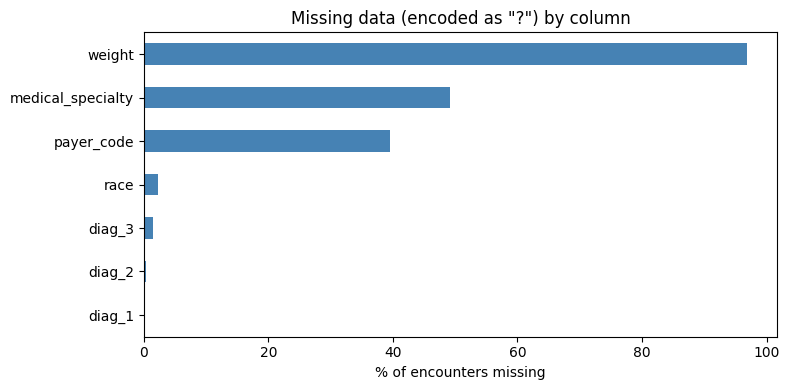

In [16]:
# Visualize it. A horizontal bar chart makes the story instant.
plt.figure(figsize=(8, 4))
missing_pct.plot(kind='barh', color='steelblue')
plt.xlabel('% of encounters missing')
plt.title('Missing data (encoded as "?") by column')
plt.gca().invert_yaxis()   # biggest bar on top
plt.tight_layout()
plt.show()

In [17]:
# Now that we KNOW '?' means missing, tell pandas: replace '?' with np.nan,
# the standard "missing" marker. From now on, pandas tools understand it.
data = data.replace('?', np.nan)

# Verify: .isna().sum() now reports real missing counts
data.isna().sum().sort_values(ascending=False).head(8)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
admission_source_desc,6781
admission_type_desc,5291
discharge_disposition_desc,3691


### 4.1 What should we DO about missing data?

There is no single rule — the decision depends on **how much** is missing and **why** (the *missingness mechanism*):

| Mechanism | Meaning | Example here |
|---|---|---|
| **MCAR** — Missing Completely At Random | Missingness has no pattern | A lab value lost due to a random system glitch |
| **MAR** — Missing At Random | Missingness depends on *other observed* variables | `medical_specialty` recorded at some hospitals but not others |
| **MNAR** — Missing Not At Random | Missingness depends on the *missing value itself* | `weight` (97% missing!) — likely only recorded when clinically relevant |

Our decisions for this dataset (we'll implement them properly in Week 3, Data Preparation):

- **`weight` (96.9% missing):** drop the column — almost no information, and MNAR.
- **`medical_specialty` (49%), `payer_code` (40%):** don't drop rows! We'd lose half the data. Options: drop the column, or keep "Missing" as its own category — missingness itself can be predictive.
- **`race` (2.2%), `diag_1/2/3` (<2%):** small — options: drop those rows, impute, or "Unknown" category.


---
# 5. Distributions: What Does the Data Look Like?

**CRISP-DM Data Understanding — Question 2: What does it look like?**

For every important variable, ask: *how are values spread out?* Histograms for numeric variables, bar charts for categorical ones.


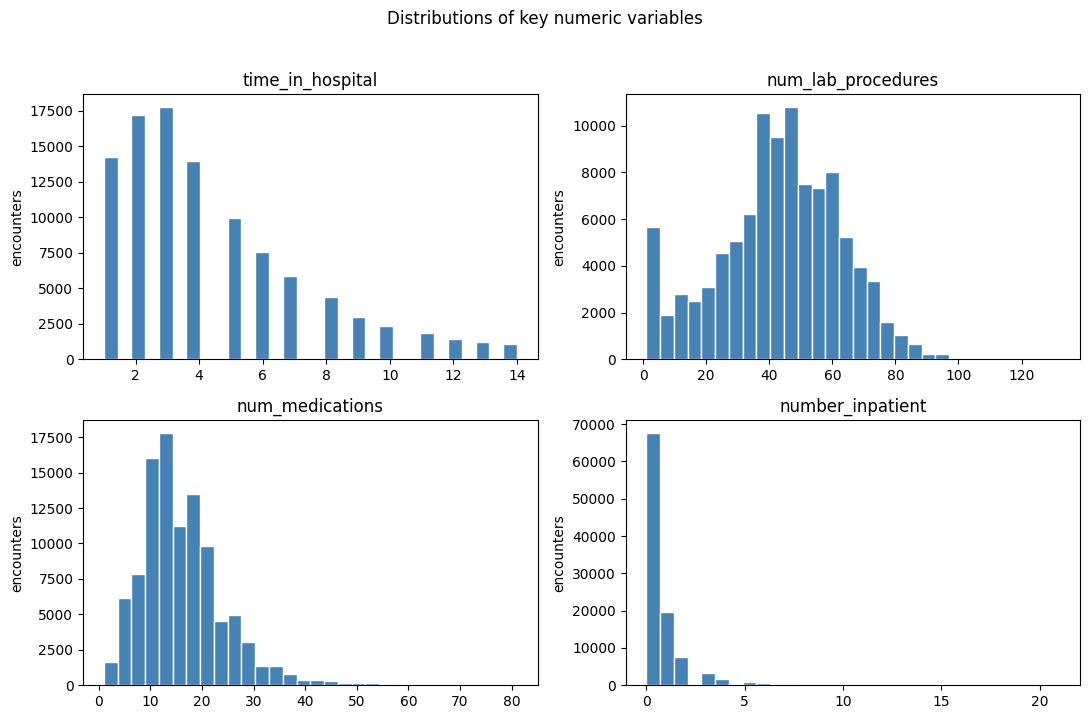

In [18]:
# Histograms for four key numeric variables in one figure.
# plt.subplots(rows, cols) creates a grid of plots; axes is a 2x2 array.
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_inpatient']
for ax, col in zip(axes.flatten(), numeric_cols):
    ax.hist(data[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('encounters')

plt.suptitle('Distributions of key numeric variables', y=1.02)
plt.tight_layout()
plt.show()

**Reading the shapes:**
- `time_in_hospital` — right-skewed: most stays are short, a few are long. Very common in healthcare data.
- `num_lab_procedures` — roughly bell-shaped with a bump near zero.
- `number_inpatient` (prior inpatient visits) — extremely skewed: most patients have 0, a few have many. Skew like this often calls for a transformation later (Week 3).


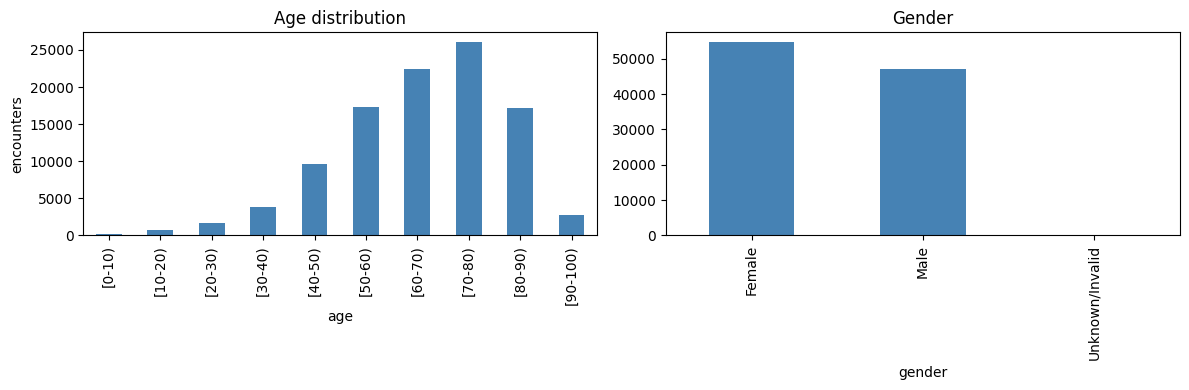

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [19]:
# Categorical variables: use value_counts + bar charts (NOT histograms).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age comes pre-binned into 10-year brackets like [70-80)
data['age'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Age distribution')
axes[0].set_ylabel('encounters')

data['gender'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Gender')

plt.tight_layout()
plt.show()

# Always PRINT the counts too — small categories can be invisible in a plot!
print(data['gender'].value_counts())

**Two findings:**
1. This is an **older population** — encounters peak in the 70–80 bracket. Our model will be trained mostly on older patients; will it work as well for 20-year-olds? (Remember this for Section 8.)
2. `gender` has **3 values** — including `Unknown/Invalid` with only 3 encounters. The bar is invisible in the plot; only the printed counts reveal it. *Always look at the numbers, not just the picture.*


---
# 6. Outliers: Unusual Values

Outliers are values far from the rest. They may be **errors** (fix or remove) or **real but extreme** (usually keep, but know they exist — some models are sensitive to them).

A standard quick check: the **boxplot** and the **IQR rule** — values beyond 1.5 × IQR (interquartile range) from the quartiles are flagged as outliers.


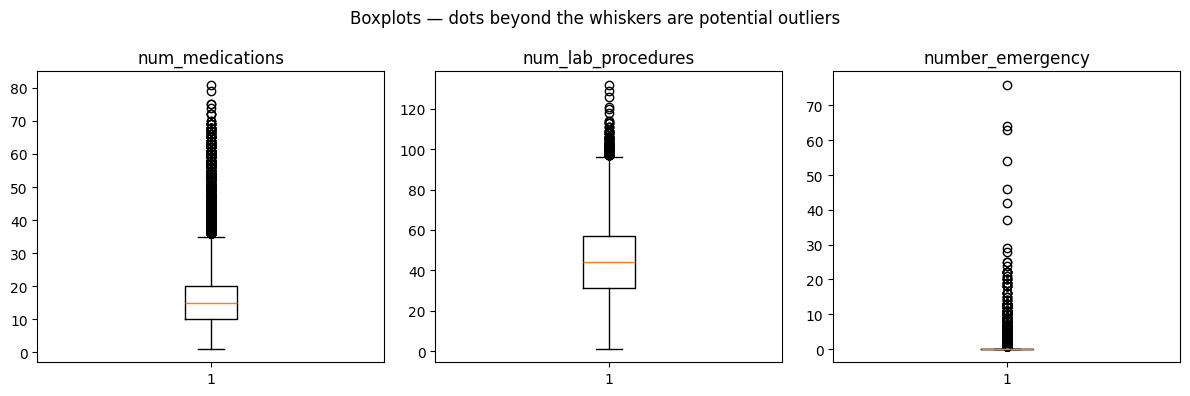

In [20]:
# Boxplots for three numeric variables.
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['num_medications', 'num_lab_procedures', 'number_emergency']):
    ax.boxplot(data[col].dropna(), vert=True)
    ax.set_title(col)
plt.suptitle('Boxplots — dots beyond the whiskers are potential outliers')
plt.tight_layout()
plt.show()

In [21]:
# The IQR rule in code, for num_medications:
q1 = data['num_medications'].quantile(0.25)     # 25th percentile
q3 = data['num_medications'].quantile(0.75)     # 75th percentile
iqr = q3 - q1                                    # interquartile range
upper_fence = q3 + 1.5 * iqr

n_outliers = (data['num_medications'] > upper_fence).sum()
print(f"Q1={q1}, Q3={q3}, IQR={iqr}, upper fence={upper_fence}")
print(f"Encounters above the fence: {n_outliers} ({n_outliers/len(data)*100:.1f}%)")

# Look at a few of the extreme rows — are they errors or plausible?
data.loc[data['num_medications'] > 60, ['age', 'time_in_hospital', 'num_medications', 'number_diagnoses']].head()

Q1=10.0, Q3=20.0, IQR=10.0, upper fence=35.0
Encounters above the fence: 2557 (2.5%)


,age,time_in_hospital,num_medications,number_diagnoses
336,[30-40),12,61,9
3280,[40-50),13,62,9
10487,[20-30),8,62,5
12314,[60-70),14,61,9
14955,[50-60),8,61,9


**Judgment call:** a patient on 70+ medications during a long hospital stay with many diagnoses is *extreme but plausible* — these look like genuinely complex patients, not data errors. We keep them, and note that in Week 3 we may cap or transform such variables for models that are outlier-sensitive.

> 🔑 **Lesson:** outlier handling is a *decision you must justify*, not an automatic deletion step.


---
# 7. Class Balance: How Rare Is Our Outcome?

**CRISP-DM Data Understanding — "Are the classes balanced?"**

For classification problems, always check how common each outcome class is *early* — it changes everything about modeling and evaluation.


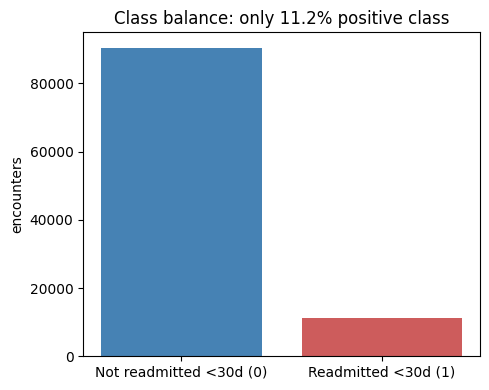

readmit_30
0    90409
1    11357
Name: count, dtype: int64


In [22]:
# Class balance of our binary target
counts = data['readmit_30'].value_counts()
pcts = data['readmit_30'].value_counts(normalize=True) * 100

plt.figure(figsize=(5, 4))
plt.bar(['Not readmitted <30d (0)', 'Readmitted <30d (1)'], counts.values, color=['steelblue', 'indianred'])
plt.ylabel('encounters')
plt.title(f'Class balance: only {pcts[1]:.1f}% positive class')
plt.tight_layout()
plt.show()
print(counts)

**Only ~11% of encounters are 30-day readmissions.** Consequences we will deal with later in the course:

- **Accuracy is misleading:** predicting "no readmission" for everyone scores ~89% accuracy and helps nobody. → Week 6: precision, recall, F1, ROC-AUC.
- **Models need help with rare classes:** class weights, resampling, threshold tuning. → Weeks 5 & 11.
- Recall from last week's slides: for this problem **false negatives** (missing a truly high-risk patient) are the costly error → **recall/sensitivity** will matter most.


---
# 8. Could the Data Be Biased? (Data Understanding Is Also Ethical)

A "routine" `value_counts()` can be a **fairness check**. Whatever groups dominate the training data are the groups the model will serve best. Let's look at who is actually *in* our data.


In [23]:
# Race distribution — counts AND percentages
race_counts = data['race'].value_counts(dropna=False)   # dropna=False also shows missing
race_pcts = data['race'].value_counts(dropna=False, normalize=True) * 100

race_table = pd.DataFrame({'encounters': race_counts, 'percent': race_pcts.round(1)})
race_table

,encounters,percent
race,,
Caucasian,76099,74.8
AfricanAmerican,19210,18.9
NaN,2273,2.2
Hispanic,2037,2.0
Other,1506,1.5
Asian,641,0.6


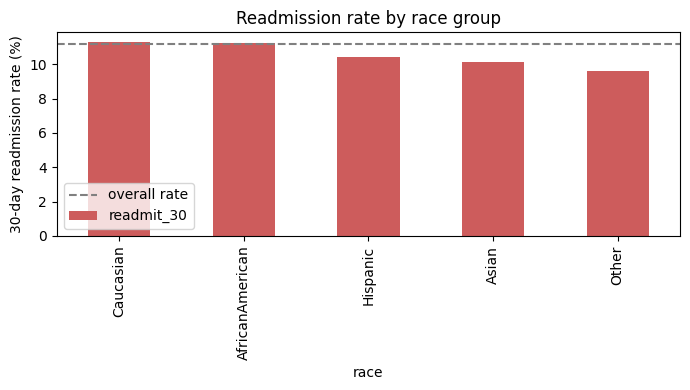

In [24]:
# Does the readmission rate differ across groups?
# .groupby(column)[target].mean() gives the positive rate per group.
readmit_by_race = data.groupby('race')['readmit_30'].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7, 4))
readmit_by_race.plot(kind='bar', color='indianred')
plt.ylabel('30-day readmission rate (%)')
plt.title('Readmission rate by race group')
plt.axhline(data['readmit_30'].mean() * 100, color='gray', linestyle='--', label='overall rate')
plt.legend()
plt.tight_layout()
plt.show()

### Discussion — think, then discuss with your neighbor:

1. ~75% of encounters are from Caucasian patients. **If one group dominates the training data, who does the model work best for?**
2. Earlier we considered dropping rows with missing values. `race` is missing for ~2,200 encounters. **Who might we silently remove from the data — and could that removal itself be biased?**
3. What could we do about it? (Collect more data; report performance **separately per group**; reweight; involve domain experts.)

> 🔑 **Lesson:** checking representation and group-level outcomes is part of *Data Understanding* — not an optional add-on at the end. We return to this properly in **Week 13: Responsible AI**, where we'll evaluate our final model's fairness formally.

*(This maps to ABET Student Outcome 4.2: identify potential ethical concerns and their impacts on stakeholders.)*


1. I believe that because White patients have approximately 75% enconters, then that group would dominate the training data. This would suggest the the model will have the most opportunity to learn patterns that characterize White patients.

2. There might be prsons that identify as biracial/multiracial or identity in way that does not fit the available categories. So we would not know who we are removing. Missing race information may also be indicative of how hospitals collect racial information.

3. I would review the codebook and hopefully gather some additional information on how the hospital gathered data on race and ethnicity.

---
# 9. Data Leakage: The Silent Model Killer

**Data leakage** = information available at training time that would NOT be available at prediction time (or that lets the model "cheat"). A leaky model looks brilliant in your notebook and fails in the real world.

Two concrete leakage risks *already visible* in our dataset:


In [25]:
# LEAKAGE RISK 1: Patients who died or went to hospice CANNOT be readmitted.
# The discharge_disposition column tells us this. If we leave these rows in,
# the model learns 'discharged to hospice => never readmitted' — technically true,
# clinically useless, and it inflates our performance metrics.
died_or_hospice = data['discharge_disposition_desc'].str.contains('Expired|Hospice', case=False, na=False)
print("Encounters ending in death or hospice:", died_or_hospice.sum())

data.loc[died_or_hospice, 'discharge_disposition_desc'].value_counts()

Encounters ending in death or hospice: 2423


,count
discharge_disposition_desc,
Expired,1642
Hospice / home,399
Hospice / medical facility,372
"Expired at home. Medicaid only, hospice.",8
"Expired in a medical facility. Medicaid only, hospice.",2


In [26]:
# LEAKAGE RISK 2: The same patient appearing in both training and test data.
# ~30% of encounters are repeat visits (Section 2). If we split rows randomly,
# the model can 'recognize' patients it already saw and cheat.
# The fix (Week 6): split by PATIENT, not by encounter — e.g., GroupKFold.
n_repeat = len(data) - data['patient_nbr'].nunique()
print(f"Repeat-visit encounters: {n_repeat} ({n_repeat/len(data)*100:.0f}% of all rows)")

Repeat-visit encounters: 30248 (30% of all rows)


**Decisions we are recording for Week 3 (Data Preparation):**
1. Remove encounters ending in death or hospice discharge (~2,400 rows) — readmission is undefined for them.
2. When we split train/test, split **by patient**, never by row.

> 🔑 **Lesson:** leakage is found by *thinking about the real-world prediction moment* ("what do we know at discharge time?"), not by any automatic tool.


---
# 10. Summary: Our Data Understanding Report

What we now know about our dataset — and the decisions we've queued up for **Week 3: Feature Engineering & Data Preparation**:

| Finding | Decision for Week 3 |
|---|---|
| 101,766 encounters, 71,518 unique patients | Split by **patient** to avoid leakage |
| `'?'` encodes missing values | Already converted to NaN |
| `weight` 97% missing, `medical_specialty` 49%, `payer_code` 40% | Drop `weight`; treat others as "Missing" category or drop columns — **not** rows |
| `race` 2.2% missing | Decide: impute / "Unknown" category; check bias implications |
| Target `readmit_30` only ~11% positive | Use recall-focused metrics; imbalance techniques (Weeks 5–6, 11) |
| Numeric variables heavily right-skewed | Consider transforms / capping |
| ~2,400 encounters end in death/hospice | Remove — readmission undefined |
| 75% of encounters from one race group | Evaluate model performance **per group** (Week 13) |

**This table *is* the deliverable of CRISP-DM Stage 2.** In industry, this becomes a short "data understanding report" your team signs off on before anyone trains a model.


---
# 🏋️ In-Class Activity (finish as homework if needed)

Work in the cells below. Add comments explaining each step — your future self is your most important collaborator.

**Q1.** What percentage of encounters involve patients aged 60 or older? *(Hint: `value_counts()` on `age`, or filter the bracket labels.)*

**Q2.** Compute the 30-day readmission rate (`readmit_30`) **by age bracket** and plot it as a bar chart. Which age groups have the highest risk? *(Hint: `groupby('age')['readmit_30'].mean()`)*

**Q3.** The column `number_inpatient` counts inpatient visits in the year *before* this encounter. Is it associated with 30-day readmission? Compare its mean between `readmit_30 == 1` and `readmit_30 == 0`. *(Hint: `groupby('readmit_30')['number_inpatient'].mean()`)*

**Q4 (stretch).** Find one data quality issue in this dataset that we did NOT discuss tonight. Describe it in a markdown cell and show the code that reveals it.


In [27]:
# Percentage of encounters involving patients age 60 or older

age_60_plus = data['age'].isin(['[60-70)', '[70-80)', '[80-90)', '[90-100)'])

percent_60_plus = age_60_plus.mean() * 100

print(f"Percentage of encounters age 60 or older: {percent_60_plus:.1f}%")

Percentage of encounters age 60 or older: 67.4%


In [28]:
# 30-day readmission rate by age bracket
age_readmit = data.groupby('age')['readmit_30'].mean()

age_readmit


,readmit_30
age,
[0-10),0.018634
[10-20),0.057887
[20-30),0.142426
[30-40),0.112318
[40-50),0.106040
[50-60),0.096662
[60-70),0.111284
[70-80),0.117731
[80-90),0.120835


In [29]:
# Convert to percentage
age_readmit_pct = age_readmit * 100

age_readmit_pct

,readmit_30
age,
[0-10),1.863354
[10-20),5.788712
[20-30),14.242607
[30-40),11.231788
[40-50),10.604027
[50-60),9.666203
[60-70),11.128408
[70-80),11.773055
[80-90),12.083503


It appears tht patients between the ages of 20-30 have the highest 30-day readmission rates at approximately 14.2%, followed by 80-90 years olds at 12.1%, and 70-90 year olds at 11.77%.

In [30]:
data.groupby('readmit_30')['number_inpatient'].mean()


,number_inpatient
readmit_30,
0,0.561648
1,1.224003


Patients readmitted within 30 days had an average of 1.22 hospital visits in the previous year, compared with 0.56 visits among pateients who were not readmitted within 30 days.

In [31]:
# Look at unique values and frequencies in categorical variables
for col in data.select_dtypes(include='object').columns:
    print("\n", col)
    print(data[col].value_counts(dropna=False).head(15))



 race
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

 gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

 age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

 weight
weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

 payer_code
payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
PO       592
DM       549
CH       146
WC       135
OT        95
Name: count, dtype: int64

 

In [32]:
data.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmit_30
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607,0.111599
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600,0.314874
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000,0.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000,0.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000,0.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000,1.000000


In terms of data quality, I would want to know what these variables were missing, NAN, not available, or not mapped in the admission source. Of course I would go back to the codebook and look further to understand this. This would be the next variable of exploration for me. It this instance, it would be important to determine how the hospital coded this data.

---
# 📌 Before Next Class

1. **Create a GitHub repository** for this course. Suggested name: `MSBD-566-Predictive-Modeling`.
2. **Upload tonight's completed notebook** (with your activity answers and your own notes/comments).
3. Be ready to **share your repository link** on Blackboard → Assignments & Discussion Board.

Your repository is your **semester-long coding portfolio** — every week's notebook goes in it, and it will be submitted at the end of the course.

**Next week (Week 3):** Feature Engineering & Data Preparation — we take tonight's decision table and actually build the clean, model-ready dataset.
